In [2]:
import os
# Esto mostrará la lista de archivos que están en la carpeta actual
print(os.listdir())

['.ipynb_checkpoints', 'aire.csv', 'Analisis_Aire_Ciclovias.ipynb', 'analisis_final_lima.png', 'analisis_pm10_ciclovias.png', 'analisis_pm25_ciclovias.png', 'ciclovias.csv']


In [3]:
# Definimos los nombres originales (largos) y los nuevos (cortos)
nombres = {
    'Monitoreo de los contaminantes del aire en Lima Metropolitana - [Servicio Nacional de Meteorología e Hidrología del Perú - SENAMHI]_1.csv': 'aire.csv',
    'CICLOVIAS EXISTENTES.csv': 'ciclovias.csv'
}

# Iteramos para renombrar cada archivo
for nombre_viejo, nombre_nuevo in nombres.items():
    try:
        os.rename(nombre_viejo, nombre_nuevo)
        print(f" Éxito: '{nombre_viejo}' ahora es '{nombre_nuevo}'")
    except FileNotFoundError:
        print(f" Aviso: El archivo '{nombre_viejo}' no se encontró (quizás ya lo renombraste).")
    except Exception as e:
        print(f" Error al renombrar '{nombre_viejo}': {e}")

# Verificamos el contenido de la carpeta
print("\nArchivos actuales en la carpeta:")
print(os.listdir())

 Aviso: El archivo 'Monitoreo de los contaminantes del aire en Lima Metropolitana - [Servicio Nacional de Meteorología e Hidrología del Perú - SENAMHI]_1.csv' no se encontró (quizás ya lo renombraste).
 Aviso: El archivo 'CICLOVIAS EXISTENTES.csv' no se encontró (quizás ya lo renombraste).

Archivos actuales en la carpeta:
['.ipynb_checkpoints', 'aire.csv', 'Analisis_Aire_Ciclovias.ipynb', 'analisis_final_lima.png', 'analisis_pm10_ciclovias.png', 'analisis_pm25_ciclovias.png', 'ciclovias.csv']


In [4]:
import pandas as pd

# Cargar archivos
df_aire = pd.read_csv('aire.csv', encoding='latin-1')
df_ciclo = pd.read_csv('ciclovias.csv', sep=';', encoding='latin-1')

# Ver resumen de calidad del aire
print("--- Diagnóstico Aire ---")
print(df_aire[['PM10', 'PM2_5', 'NO2']].isnull().sum()) # Cuenta vacíos

# Selección de columnas para el df de ciclovías
columnas_ciclo = ['DISTRITO_CICLOVIA', 'LONGITUD_KM', 'TIPO_VIA']
df_ciclo_red = df_ciclo[columnas_ciclo].copy()

# Estandarización
# Convertimos a mayúsculas y quitamos espacios extra para asegurar el cruce de datos
df_ciclo_red['DISTRITO_JOIN'] = df_ciclo_red['DISTRITO_CICLOVIA'].str.upper().str.strip()

# Cálculos para el Recuento Clave
total_km = df_ciclo_red['LONGITUD_KM'].sum()
total_tramos = len(df_ciclo_red)
distritos_unicos = df_ciclo_red['DISTRITO_JOIN'].nunique()

# Impresión de resultados
print("--- RESUMEN CLAVE: INFRAESTRUCTURA CICLISTA ---")
print("Total de kilómetros registrados en Lima: {:.2f} km".format(total_km))
print("Número total de tramos o segmentos: {}".format(total_tramos))
print("Cantidad de distritos con ciclovías: {}".format(distritos_unicos))

--- Diagnóstico Aire ---
PM10     196812
PM2_5    210203
NO2      278602
dtype: int64
--- RESUMEN CLAVE: INFRAESTRUCTURA CICLISTA ---
Total de kilómetros registrados en Lima: 332.43 km
Número total de tramos o segmentos: 335
Cantidad de distritos con ciclovías: 34


In [2]:
# Definimos las columnas que queremos proteger
columnas_contaminantes = ['PM10', 'PM2_5', 'NO2']

# Registramos el tamaño original para el reporte
total_original = len(df_aire)

# Borramos la fila SOLO si los TRES están vacíos al mismo tiempo (how='all')
df_aire_analisis = df_aire.dropna(subset=columnas_contaminantes, how='all')

# Calculamos cuántos registros quedaron
total_final = len(df_aire_analisis)

# Reporte de resultados usando .format()
print("--- Reporte de Limpieza ---")
print("Registros iniciales: {}".format(total_original))
print("Registros eliminados (sin ningún dato útil): {}".format(total_original - total_final))
print("Registros útiles para el análisis: {}".format(total_final))

# Verificación de datos por cada variable
print("\nMediciones reales recuperadas:")
print(df_aire_analisis[columnas_contaminantes].notnull().sum())

--- Reporte de Limpieza ---
Registros iniciales: 577794
Registros eliminados (sin ningún dato útil): 113156
Registros útiles para el análisis: 464638

Mediciones reales recuperadas:
PM10     380982
PM2_5    367591
NO2      299192
dtype: int64


In [5]:
import unicodedata

# Función para normalizar nombres (Elimina tildes y estandariza texto)
def normalizar(texto):
    if pd.isna(texto): return ""
    # Eliminar acentos
    texto = "".join(c for c in unicodedata.normalize('NFD', str(texto)) if unicodedata.category(c) != 'Mn')
    # Mayúsculas, quitar guiones bajos y espacios extra
    return texto.upper().replace('_', ' ').strip()

# Aplicamos la normalización para que los nombres coincidan
df_aire['DISTRITO_NORM'] = df_aire['DISTRITO'].apply(normalizar)
df_ciclo['DISTRITO_NORM'] = df_ciclo['DISTRITO_CICLOVIA'].apply(normalizar)

# Agrupamos los datos para tener un resumen por distrito
# Promedio de contaminación (Aire)
resumen_aire = df_aire.groupby('DISTRITO_NORM')[['PM10', 'PM2_5', 'NO2']].mean().reset_index()
# Total de KM (Ciclovías)
resumen_ciclo = df_ciclo.groupby('DISTRITO_NORM')['LONGITUD_KM'].sum().reset_index()

# El CRUCE (Merge) - Usamos "inner" para quedarnos solo con los que tienen ambos datos
df_final = pd.merge(resumen_aire, resumen_ciclo, on='DISTRITO_NORM', how='inner')

# Ordenamos por NO2 (Tráfico) para ver los resultados
df_final = df_final.sort_values(by='NO2', ascending=False)

# Impresión de resultados con .format()
print("--- RESULTADO DEL CRUCE: AIRE VS MOVILIDAD ---")
print("Distritos analizados con éxito: {}".format(len(df_final)))
print("\nTabla final de resultados:")
display(df_final)

--- RESULTADO DEL CRUCE: AIRE VS MOVILIDAD ---
Distritos analizados con éxito: 6

Tabla final de resultados:


,DISTRITO_NORM,PM10,PM2_5,NO2,LONGITUD_KM
2,SAN JUAN DE LURIGANCHO,74.874532,31.384925,31.383555,11.66
4,SANTA ANITA,62.944337,30.042924,25.373188,4.43
3,SAN MARTIN DE PORRES,41.512554,18.684188,23.081680,20.25
1,SAN BORJA,58.768756,18.666638,20.954854,28.40
0,JESUS MARIA,30.715066,16.907733,17.859677,13.61
5,VILLA MARIA DEL TRIUNFO,97.433081,26.257074,17.746077,0.29


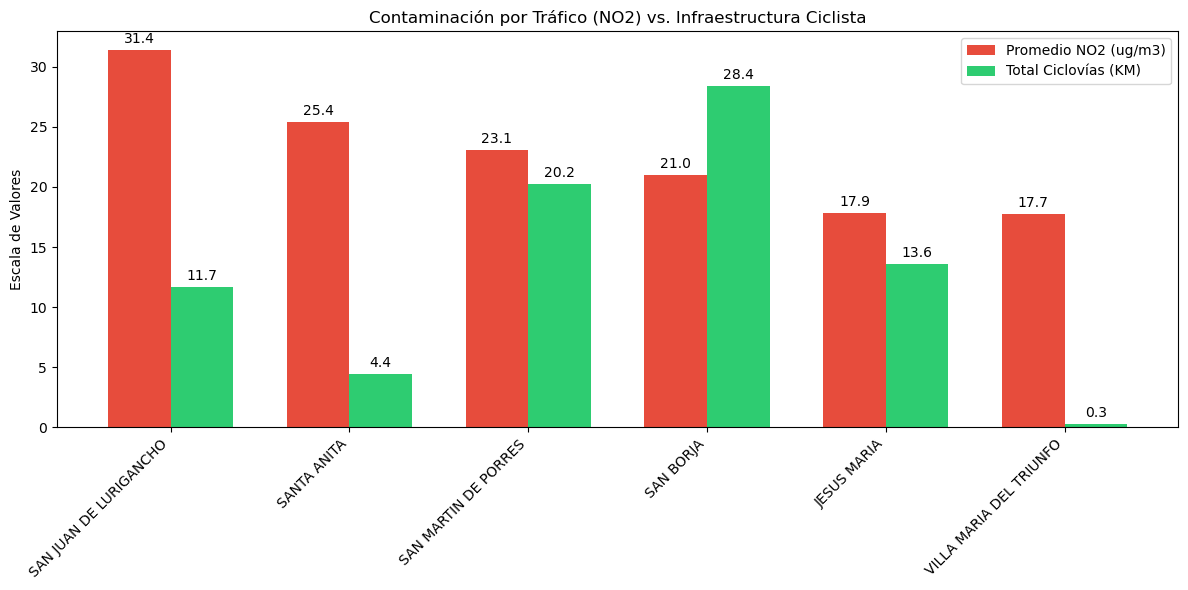

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Preparar los datos para el gráfico
distritos = df_final['DISTRITO_NORM']
valores_no2 = df_final['NO2']
valores_km = df_final['LONGITUD_KM']

# Configurar la posición de las barras
x = np.arange(len(distritos))  # Ubicación de los grupos
ancho = 0.35                 # Ancho de cada barra

# Crear el gráfico
fig, ax = plt.subplots(figsize=(12, 6))

# Dibujamos las dos barras (NO2 y KM)
barra1 = ax.bar(x - ancho/2, valores_no2, ancho, label='Promedio NO2 (ug/m3)', color='#e74c3c')
barra2 = ax.bar(x + ancho/2, valores_km, ancho, label='Total Ciclovías (KM)', color='#2ecc71')

# Personalización del diseño
ax.set_ylabel('Escala de Valores')
ax.set_title('Contaminación por Tráfico (NO2) vs. Infraestructura Ciclista')
ax.set_xticks(x)
ax.set_xticklabels(distritos, rotation=45, ha='right')
ax.legend()

# Función para poner los números encima de las barras
def poner_etiquetas(rects):
    for rect in rects:
        altura = rect.get_height()
        ax.annotate('{:.1f}'.format(altura),
                    xy=(rect.get_x() + rect.get_width() / 2, altura),
                    xytext=(0, 3), 
                    textcoords="offset points",
                    ha='center', va='bottom')

poner_etiquetas(barra1)
poner_etiquetas(barra2)

# Ajustar y mostrar
plt.tight_layout()
plt.savefig('analisis_final_lima.png') # Esto guarda el gráfico como imagen en tu carpeta

Gráfico de PM10 generado con éxito.


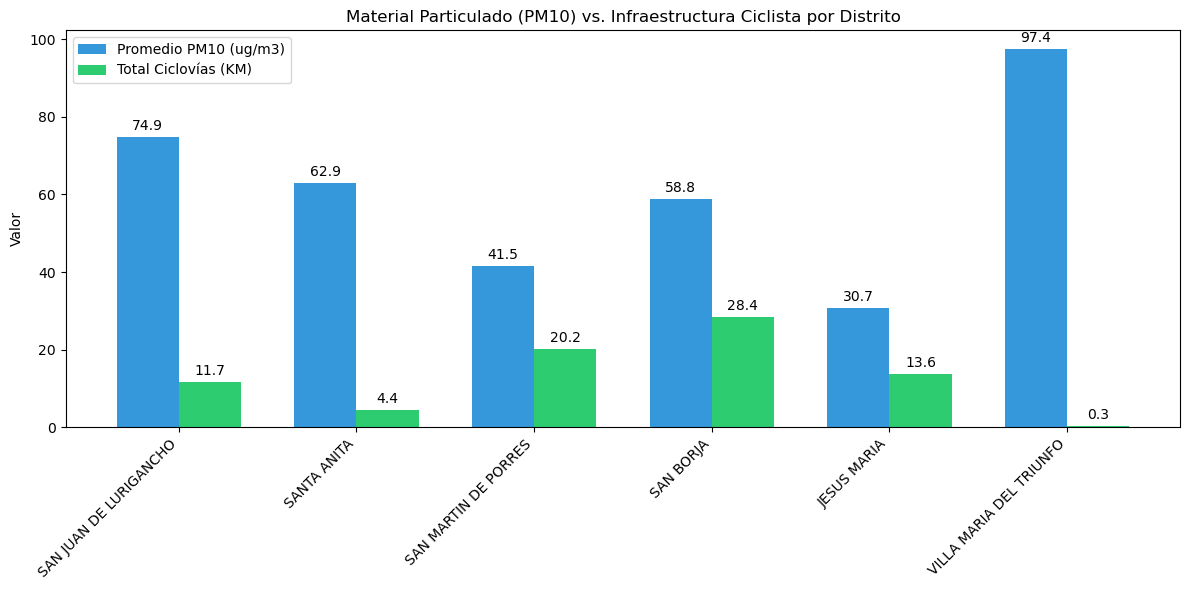

In [5]:
# Preparar datos
distritos = df_final['DISTRITO_NORM']
valores_pm10 = df_final['PM10']
valores_km = df_final['LONGITUD_KM']

x = np.arange(len(distritos))
ancho = 0.35

# Crear gráfico
fig, ax = plt.subplots(figsize=(12, 6))
barra1 = ax.bar(x - ancho/2, valores_pm10, ancho, label='Promedio PM10 (ug/m3)', color='#3498db') # Azul
barra2 = ax.bar(x + ancho/2, valores_km, ancho, label='Total Ciclovías (KM)', color='#2ecc71')

# Diseño y etiquetas 
ax.set_ylabel('Valor')
ax.set_title('Material Particulado (PM10) vs. Infraestructura Ciclista por Distrito')
ax.set_xticks(x)
ax.set_xticklabels(distritos, rotation=45, ha='right')
ax.legend()

# Función para etiquetas 
def poner_etiquetas(rects):
    for rect in rects:
        altura = rect.get_height()
        ax.annotate('{:.1f}'.format(altura),
                    xy=(rect.get_x() + rect.get_width() / 2, altura),
                    xytext=(0, 3), 
                    textcoords="offset points",
                    ha='center', va='bottom')

poner_etiquetas(barra1)
poner_etiquetas(barra2)

plt.tight_layout()
plt.savefig('analisis_pm10_ciclovias.png')
print("Gráfico de PM10 generado con éxito.")

Gráfico de PM2.5 generado con éxito.


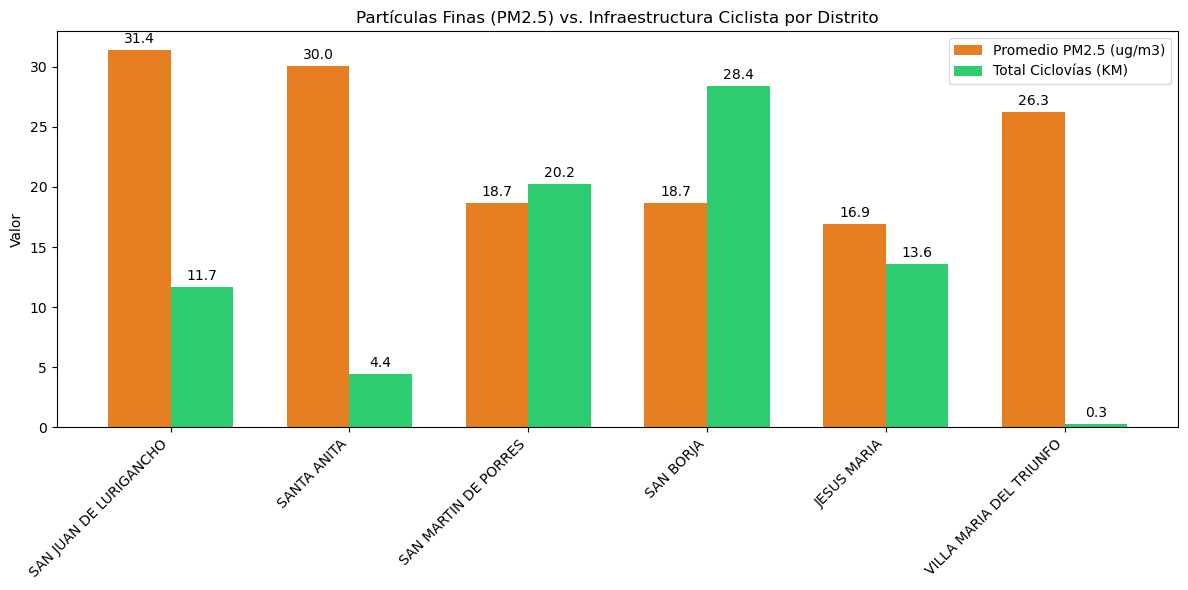

In [6]:
# Preparar datos
valores_pm25 = df_final['PM2_5']

# Crear gráfico
fig, ax = plt.subplots(figsize=(12, 6))
barra1 = ax.bar(x - ancho/2, valores_pm25, ancho, label='Promedio PM2.5 (ug/m3)', color='#e67e22')
barra2 = ax.bar(x + ancho/2, valores_km, ancho, label='Total Ciclovías (KM)', color='#2ecc71')

# Diseño
ax.set_ylabel('Valor')
ax.set_title('Partículas Finas (PM2.5) vs. Infraestructura Ciclista por Distrito')
ax.set_xticks(x)
ax.set_xticklabels(distritos, rotation=45, ha='right')
ax.legend()

poner_etiquetas(barra1)
poner_etiquetas(barra2)

plt.tight_layout()
plt.savefig('analisis_pm25_ciclovias.png')
print("Gráfico de PM2.5 generado con éxito.")